# The Barcelona Housing Paradox
## A Data-Driven Policy Analysis (2000–2025)

### 1. Data Loading and Initial Exploration

The primary dataset is sourced from INCASÒL (Institut Català del Sòl) via the 
Generalitat de Catalunya's official housing statistics portal. It contains 
quarterly and annual rental data by district and neighbourhood for the city 
of Barcelona, covering the period from 2000 to 2025.

**Dataset:** Average rent per m² (€/m²) by district — Annual series  
**Source:** Generalitat de Catalunya — Mercat de Lloguer  
**Coverage:** 10 municipal districts, 2000–2025

In [2]:
import pandas as pd

df = pd.read_excel('anual_bcn_lloguer_m2.xlsx')

df.head()

,Evolució anual del mercat de lloguer a Barcelona,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25,Unnamed: 26,Unnamed: 27
0,Mitjana anual del lloguer contractual per metr...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NOTA: no es publica la informació dels àmbits ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Codi,NaN,2025.000000,2024,2023,2022,2021,2020,2019.000000,2018,...,2009.000000,2008.000000,2007.000000,2006.000000,2005.000000,2004.000000,2003.000000,2002.000000,2001.000000,2000.000000
4,NaN,Barcelona,16.671056,16.125009,16.104901,14.5397,13.205191,13.886346,13.982565,13.423019,...,11.919688,12.242878,11.544505,10.556925,9.637512,8.676605,7.995923,7.624639,6.873029,6.002394


In [3]:
df = pd.read_excel('anual_bcn_lloguer_m2.xlsx', skiprows=3)

df.head()

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25,Unnamed: 26,Unnamed: 27
0,Codi,NaN,2025.000000,2024,2023,2022,2021,2020,2019.000000,2018,...,2009.000000,2008.000000,2007.000000,2006.000000,2005.000000,2004.000000,2003.000000,2002.000000,2001.000000,2000.000000
1,NaN,Barcelona,16.671056,16.125009,16.104901,14.5397,13.205191,13.886346,13.982565,13.423019,...,11.919688,12.242878,11.544505,10.556925,9.637512,8.676605,7.995923,7.624639,6.873029,6.002394
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,Districtes municipals,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1,Ciutat Vella,18.133475,16.603084,16.661738,15.789267,13.241396,14.341542,14.772022,14.456812,...,12.415282,12.565050,11.603486,10.690951,9.764864,8.564200,7.585766,7.289917,6.431010,5.528871


In [4]:
df = pd.read_excel('anual_bcn_lloguer_m2.xlsx', skiprows=4)

df.head()

,Codi,Unnamed: 1,2025,2024,2023,2022,2021,2020,2019,2018,...,2009,2008,2007,2006,2005,2004,2003,2002,2001,2000
0,NaN,Barcelona,16.671056,16.125009,16.104901,14.5397,13.205191,13.886346,13.982565,13.423019,...,11.919688,12.242878,11.544505,10.556925,9.637512,8.676605,7.995923,7.624639,6.873029,6.002394
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,Districtes municipals,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1,Ciutat Vella,18.133475,16.603084,16.661738,15.789267,13.241396,14.341542,14.772022,14.456812,...,12.415282,12.565050,11.603486,10.690951,9.764864,8.564200,7.585766,7.289917,6.431010,5.528871
4,2,Eixample,16.840435,16.641438,16.512199,14.93477,13.346103,14.216685,14.340369,13.730798,...,11.643396,11.891041,11.263929,10.262810,9.485812,8.453163,7.881907,7.466125,6.809718,5.753807


### 2. Data Cleaning

The raw file contains metadata rows that need to be removed before analysis:
- Row 0: city-level aggregate (Barcelona total) — preserved separately
- Row 1: empty spacing row
- Row 2: section label ('Districtes municipals')

District-level data begins at row 3.

In [5]:
# Save Barcelona total separately
barcelona_total = df.iloc[0]

# Keep only district rows (remove rows 0, 1, 2)
df = df.drop(index=[0, 1, 2]).reset_index(drop=True)

df.head()

,Codi,Unnamed: 1,2025,2024,2023,2022,2021,2020,2019,2018,...,2009,2008,2007,2006,2005,2004,2003,2002,2001,2000
0,1,Ciutat Vella,18.133475,16.603084,16.661738,15.789267,13.241396,14.341542,14.772022,14.456812,...,12.415282,12.565050,11.603486,10.690951,9.764864,8.564200,7.585766,7.289917,6.431010,5.528871
1,2,Eixample,16.840435,16.641438,16.512199,14.93477,13.346103,14.216685,14.340369,13.730798,...,11.643396,11.891041,11.263929,10.262810,9.485812,8.453163,7.881907,7.466125,6.809718,5.753807
2,3,Sants-Montjuïc,16.410062,15.645093,16.325533,14.077913,12.966142,13.643583,13.493590,13.013694,...,11.905331,12.220043,11.280374,10.486616,9.505815,8.682147,7.765397,7.510634,6.681541,6.054531
3,4,Les Corts,17.655265,17.388903,16.768752,15.232212,13.841062,14.671889,14.953950,14.521215,...,12.911521,13.377186,13.010030,11.852607,10.782921,9.959508,9.343052,8.895366,8.642025,7.590490
4,5,Sarrià-Sant Gervasi,19.064182,18.358875,18.244033,16.22702,14.864003,15.592313,15.712232,15.438745,...,12.853166,13.288333,12.709288,11.631103,10.847408,10.004104,9.354017,9.063606,8.239989,7.403037


In [6]:
df.columns.tolist()

['Codi',
 'Unnamed: 1',
 '2025',
 2024,
 2023,
 2022,
 2021,
 2020,
 2019,
 2018,
 2017,
 2016,
 2015,
 2014,
 2013,
 2012,
 2011,
 2010,
 2009,
 2008,
 2007,
 2006,
 2005,
 2004,
 2003,
 2002,
 2001,
 2000]

### 3. Column Renaming and Type Standardisation

The column `Unnamed: 1` is renamed to `Districte`. 
Year columns are standardised to integer type to ensure consistency across the full time series.

In [7]:
# Rename district column
df = df.rename(columns={'Unnamed: 1': 'Districte'})

# Standardise all year columns to integer
df.columns = ['Codi', 'Districte'] + [int(col) for col in df.columns[2:]]

df.columns.tolist()

['Codi',
 'Districte',
 2025,
 2024,
 2023,
 2022,
 2021,
 2020,
 2019,
 2018,
 2017,
 2016,
 2015,
 2014,
 2013,
 2012,
 2011,
 2010,
 2009,
 2008,
 2007,
 2006,
 2005,
 2004,
 2003,
 2002,
 2001,
 2000]

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 88 entries, 0 to 87
Data columns (total 28 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Codi       85 non-null     object 
 1   Districte  84 non-null     str    
 2   2025       83 non-null     float64
 3   2024       83 non-null     object 
 4   2023       83 non-null     object 
 5   2022       83 non-null     object 
 6   2021       83 non-null     object 
 7   2020       83 non-null     object 
 8   2019       83 non-null     float64
 9   2018       83 non-null     object 
 10  2017       83 non-null     object 
 11  2016       83 non-null     float64
 12  2015       83 non-null     float64
 13  2014       83 non-null     object 
 14  2013       10 non-null     float64
 15  2012       10 non-null     float64
 16  2011       10 non-null     float64
 17  2010       10 non-null     float64
 18  2009       10 non-null     float64
 19  2008       10 non-null     float64
 20  2007       10 non-null 

In [9]:
df[2024].unique()

array([16.603084134032628, 16.641437695556558, 15.645093197387117,
       17.38890334023618, 18.358875252422827, 17.497989728355034,
       14.499193146822348, 13.05828655677281, 13.655981562833402,
       16.23555895841007, nan, 15.943019068419218, 16.22130882882677,
       19.97192233216883, 17.080626139191224, 15.900414700473773,
       16.805830727871772, 16.76291834080274, 16.986084150288978,
       16.73340900022927, 16.1433605131686, 16.412833429522358,
       8.676622059977523, 12.019254747890507, 15.637088657860765,
       15.63537247636025, 18.717549873242493, 16.047267468467535,
       15.960933903379535, 17.434994490150956, 16.426051223639206,
       19.292450637151905, 16.28230779295833, 19.264390858172135,
       19.737576185662448, 18.079007017120375, 18.752671973132443,
       17.053357640379087, 17.757284520261535, 14.664232463992306,
       16.422293391150866, 17.885784457148763, 17.47658713800269,
       15.720253375060535, 15.718676198390071, 14.992782970639043,
   

### 4. Handling Missing Values

Some cells contain the string `'nd'` (no data), used by the Generalitat de Catalunya 
to indicate unavailable data. These values are replaced with `NaN` to allow proper 
numeric conversion without discarding entire rows.

In [10]:
# Replace 'nd' with NaN and convert year columns to float
year_cols = [col for col in df.columns if isinstance(col, int)]

df[year_cols] = df[year_cols].replace('nd', pd.NA).astype(float)

df.info()

TypeError: float() argument must be a string or a real number, not 'NAType'

In [11]:
import numpy as np

df[year_cols] = df[year_cols].replace('nd', np.nan).astype(float)

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 88 entries, 0 to 87
Data columns (total 28 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Codi       85 non-null     object 
 1   Districte  84 non-null     str    
 2   2025       83 non-null     float64
 3   2024       82 non-null     float64
 4   2023       81 non-null     float64
 5   2022       81 non-null     float64
 6   2021       82 non-null     float64
 7   2020       81 non-null     float64
 8   2019       83 non-null     float64
 9   2018       82 non-null     float64
 10  2017       82 non-null     float64
 11  2016       83 non-null     float64
 12  2015       83 non-null     float64
 13  2014       82 non-null     float64
 14  2013       10 non-null     float64
 15  2012       10 non-null     float64
 16  2011       10 non-null     float64
 17  2010       10 non-null     float64
 18  2009       10 non-null     float64
 19  2008       10 non-null     float64
 20  2007       10 non-null 

In [12]:
df[['Codi', 'Districte']].head(20)

,Codi,Districte
0,1,Ciutat Vella
1,2,Eixample
2,3,Sants-Montjuïc
3,4,Les Corts
4,5,Sarrià-Sant Gervasi
5,6,Gràcia
6,7,Horta-Guinardó
7,8,Nou Barris
8,9,Sant Andreu
9,10,Sant Martí


### 5. Separating Districts and Neighbourhoods

The dataset contains two levels of geographic granularity:
- **10 districts** (districtes): full time series from 2000 to 2025
- **73 neighbourhoods** (barris): available from 2013 onwards

Both levels are preserved separately for different analytical purposes.

In [13]:
# Districts: first 10 rows
df_distritos = df.iloc[0:10].reset_index(drop=True)

# Neighbourhoods: everything from row 12 onwards
df_barris = df.iloc[12:].reset_index(drop=True)

print(f"Distritos: {len(df_distritos)} rows")
print(f"Barris: {len(df_barris)} rows")

Distritos: 10 rows
Barris: 76 rows


In [14]:
df_barris.tail(10)

,Codi,Districte,2025,2024,2023,2022,2021,2020,2019,2018,...,2009,2008,2007,2006,2005,2004,2003,2002,2001,2000
66,67,la Vila Olímpica del Poblenou,20.816206,21.871998,20.380123,19.105777,16.762442,17.656045,17.547807,16.866786,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
67,68,el Poblenou,18.286586,18.113001,17.775290,16.508805,14.330952,14.918121,15.083231,14.459997,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
68,69,Diagonal Mar i el Front Marítim del Poblenou,22.386218,19.629087,18.810574,17.243561,15.664649,16.664813,17.261528,15.270815,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
69,70,el Besòs i el Maresme,13.159185,13.439994,12.494456,12.125857,11.344426,11.910099,11.340307,10.947029,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
70,71,Provençals del Poblenou,16.846682,16.123392,16.348464,14.539182,13.472107,13.975188,14.110284,13.633985,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
71,72,Sant Martí de Provençals,13.572016,14.098404,13.536344,12.126000,11.493683,11.777952,11.903843,11.503599,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
72,73,la Verneda i la Pau,14.171006,14.517446,16.297611,11.420926,11.073128,11.545577,11.475549,11.190063,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
73,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
74,(1) La informació està elaborada a partir d'aq...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75,Font: Servei d'Estudis i Documentació d'Habita...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [15]:
df_barris = df_barris.iloc[:-3].reset_index(drop=True)

print(f"Barris: {len(df_barris)} rows")

Barris: 73 rows


### 6. Exporting Clean Datasets

Cleaned dataframes are exported as CSV files for use in subsequent 
analysis and visualisation stages.

In [16]:
df_distritos.to_csv('bcn_rent_distritos_clean.csv', index=False)
df_barris.to_csv('bcn_rent_barris_clean.csv', index=False)

print("Files saved successfully.")

Files saved successfully.


In [1]:
import pandas as pd
import numpy as np

df_barris = pd.read_csv('bcn_rent_barris_clean.csv')

df_barris.head()

,Codi,Districte,2025,2024,2023,2022,2021,2020,2019,2018,...,2009,2008,2007,2006,2005,2004,2003,2002,2001,2000
0,1,el Raval,16.606813,15.943019,15.890006,15.218872,12.910851,14.038781,14.323614,14.015729,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,el Barri Gòtic,16.488115,16.221309,16.436274,15.648701,12.592374,13.633715,14.298790,13.804200,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,la Barceloneta,22.698405,19.971922,18.984795,18.771757,15.997813,17.283146,17.400465,16.883300,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,"Sant Pere, Santa Caterina i la Ribera",18.606185,17.080626,17.408159,16.047235,13.592295,14.615678,15.157329,15.016393,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,el Fort Pienc,15.545892,15.900415,16.082591,14.377275,13.048153,13.900360,14.015333,13.134292,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
df_barris = df_barris.rename(columns={'Barri': 'Barris'})

In [7]:
df_barris.head()

,Codi,Barris,2025,2024,2023,2022,2021,2020,2019,2018,...,2009,2008,2007,2006,2005,2004,2003,2002,2001,2000
0,1,el Raval,16.606813,15.943019,15.890006,15.218872,12.910851,14.038781,14.323614,14.015729,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,el Barri Gòtic,16.488115,16.221309,16.436274,15.648701,12.592374,13.633715,14.298790,13.804200,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,la Barceloneta,22.698405,19.971922,18.984795,18.771757,15.997813,17.283146,17.400465,16.883300,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,"Sant Pere, Santa Caterina i la Ribera",18.606185,17.080626,17.408159,16.047235,13.592295,14.615678,15.157329,15.016393,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,el Fort Pienc,15.545892,15.900415,16.082591,14.377275,13.048153,13.900360,14.015333,13.134292,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
df_barris = df_barris.drop(columns=[2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009])


KeyError: '[2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009] not found in axis'

In [9]:
df_barris.columns.tolist()

['Codi',
 'Barris',
 '2025',
 '2024',
 '2023',
 '2022',
 '2021',
 '2020',
 '2019',
 '2018',
 '2017',
 '2016',
 '2015',
 '2014',
 '2013',
 '2012',
 '2011',
 '2010',
 '2009',
 '2008',
 '2007',
 '2006',
 '2005',
 '2004',
 '2003',
 '2002',
 '2001',
 '2000']

In [10]:
df_barris.columns = ['Codi', 'Barris'] + [int(col) for col in df_barris.columns[2:]]

In [11]:
df_barris = df_barris.drop(columns=[2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009])

In [12]:
df_barris.head()

,Codi,Barris,2025,2024,2023,2022,2021,2020,2019,2018,2017,2016,2015,2014,2013,2012,2011,2010
0,1,el Raval,16.606813,15.943019,15.890006,15.218872,12.910851,14.038781,14.323614,14.015729,13.915648,12.263660,11.1045,10.47,NaN,NaN,NaN,NaN
1,2,el Barri Gòtic,16.488115,16.221309,16.436274,15.648701,12.592374,13.633715,14.298790,13.804200,14.191885,13.042661,11.2094,10.54,NaN,NaN,NaN,NaN
2,3,la Barceloneta,22.698405,19.971922,18.984795,18.771757,15.997813,17.283146,17.400465,16.883300,19.844592,18.176978,16.3294,15.15,NaN,NaN,NaN,NaN
3,4,"Sant Pere, Santa Caterina i la Ribera",18.606185,17.080626,17.408159,16.047235,13.592295,14.615678,15.157329,15.016393,15.713611,14.089731,12.6979,11.24,NaN,NaN,NaN,NaN
4,5,el Fort Pienc,15.545892,15.900415,16.082591,14.377275,13.048153,13.900360,14.015333,13.134292,13.114796,11.757594,10.8908,9.98,NaN,NaN,NaN,NaN


In [13]:
df_barris = df_barris.drop(columns=[2013, 2012, 2011, 2010])

In [14]:
df_barris.head()

,Codi,Barris,2025,2024,2023,2022,2021,2020,2019,2018,2017,2016,2015,2014
0,1,el Raval,16.606813,15.943019,15.890006,15.218872,12.910851,14.038781,14.323614,14.015729,13.915648,12.263660,11.1045,10.47
1,2,el Barri Gòtic,16.488115,16.221309,16.436274,15.648701,12.592374,13.633715,14.298790,13.804200,14.191885,13.042661,11.2094,10.54
2,3,la Barceloneta,22.698405,19.971922,18.984795,18.771757,15.997813,17.283146,17.400465,16.883300,19.844592,18.176978,16.3294,15.15
3,4,"Sant Pere, Santa Caterina i la Ribera",18.606185,17.080626,17.408159,16.047235,13.592295,14.615678,15.157329,15.016393,15.713611,14.089731,12.6979,11.24
4,5,el Fort Pienc,15.545892,15.900415,16.082591,14.377275,13.048153,13.900360,14.015333,13.134292,13.114796,11.757594,10.8908,9.98


In [15]:
df_barris.to_csv('bcn_rent_barris_clean.csv', index=False)
print("File updated successfully.")

File updated successfully.


### 8. Reshaping: Wide to Long Format

The dataset is reshaped from wide format (years as columns) to long format 
(one row per neighbourhood per year). This structure is required 
for time series analysis and visualisation.

In [16]:
df_barris_long = df_barris.melt(
    id_vars=['Codi', 'Barris'],
    var_name='Any',
    value_name='Preu_m2'
)

df_barris_long.head(10)

,Codi,Barris,Any,Preu_m2
0,1,el Raval,2025,16.606813
1,2,el Barri Gòtic,2025,16.488115
2,3,la Barceloneta,2025,22.698405
3,4,"Sant Pere, Santa Caterina i la Ribera",2025,18.606185
4,5,el Fort Pienc,2025,15.545892
5,6,la Sagrada Família,2025,16.893433
6,7,la Dreta de l'Eixample,2025,17.400271
7,8,l'Antiga Esquerra de l'Eixample,2025,16.797803
8,9,la Nova Esquerra de l'Eixample,2025,17.314881
9,10,Sant Antoni,2025,16.261870


In [17]:
df_barris_long = df_barris_long.sort_values(by=['Codi', 'Any']).reset_index(drop=True)

df_barris_long.head(15)

,Codi,Barris,Any,Preu_m2
0,1,el Raval,2014,10.470000
1,1,el Raval,2015,11.104500
2,1,el Raval,2016,12.263660
3,1,el Raval,2017,13.915648
4,1,el Raval,2018,14.015729
5,1,el Raval,2019,14.323614
6,1,el Raval,2020,14.038781
7,1,el Raval,2021,12.910851
8,1,el Raval,2022,15.218872
9,1,el Raval,2023,15.890006


In [18]:
df_barris_long.to_csv('bcn_rent_barris_long.csv', index=False)
print("File saved successfully.")

File saved successfully.


### 9. Exploratory Data Analysis

#### 9.1 Most and Least Expensive Neighbourhoods in 2025

In [19]:
df_2025 = df_barris_long[df_barris_long['Any'] == 2025]

In [20]:
top10_caros = df_2025.sort_values(by='Preu_m2', ascending=False).head(10)
top10_caros

,Codi,Barris,Any,Preu_m2
35,3,la Barceloneta,2025,22.698405
827,69,Diagonal Mar i el Front Marítim del Poblenou,2025,22.386218
803,67,la Vila Olímpica del Poblenou,2025,20.816206
275,23,Sarrià,2025,20.487242
503,42,la Clota,2025,20.147548
287,24,les Tres Torres,2025,19.735513
299,25,Sant Gervasi - la Bonanova,2025,19.239247
311,26,Sant Gervasi - Galvany,2025,18.841334
251,21,Pedralbes,2025,18.673718
47,4,"Sant Pere, Santa Caterina i la Ribera",2025,18.606185


In [21]:
top10_baratos = df_2025.sort_values(by='Preu_m2', ascending=True).head(10) 
top10_baratos

,Codi,Barris,Any,Preu_m2
563,47,Can Peguera,2025,8.435696
695,58,Baró de Viver,2025,8.445482
587,49,Canyelles,2025,9.984464
659,55,Ciutat Meridiana,2025,10.196637
647,54,Torre Baró,2025,10.353920
671,56,Vallbona,2025,10.395397
707,59,el Bon Pastor,2025,11.361330
467,39,Sant Genís dels Agudells,2025,12.248444
635,53,la Trinitat Nova,2025,12.452447
575,48,la Guineueta,2025,12.474711


In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

In [23]:
top10_caros['tipo'] = 'Més car'
top10_baratos['tipo'] = 'Més barat'

df_top = pd.concat([top10_caros, top10_baratos]).sort_values(by='Preu_m2', ascending=True)

df_top

,Codi,Barris,Any,Preu_m2,tipo
563,47,Can Peguera,2025,8.435696,Més barat
695,58,Baró de Viver,2025,8.445482,Més barat
587,49,Canyelles,2025,9.984464,Més barat
659,55,Ciutat Meridiana,2025,10.196637,Més barat
647,54,Torre Baró,2025,10.353920,Més barat
671,56,Vallbona,2025,10.395397,Més barat
707,59,el Bon Pastor,2025,11.361330,Més barat
467,39,Sant Genís dels Agudells,2025,12.248444,Més barat
635,53,la Trinitat Nova,2025,12.452447,Més barat
575,48,la Guineueta,2025,12.474711,Més barat


#### 9.2 Price Inequality Across Barcelona Neighbourhoods (2025)

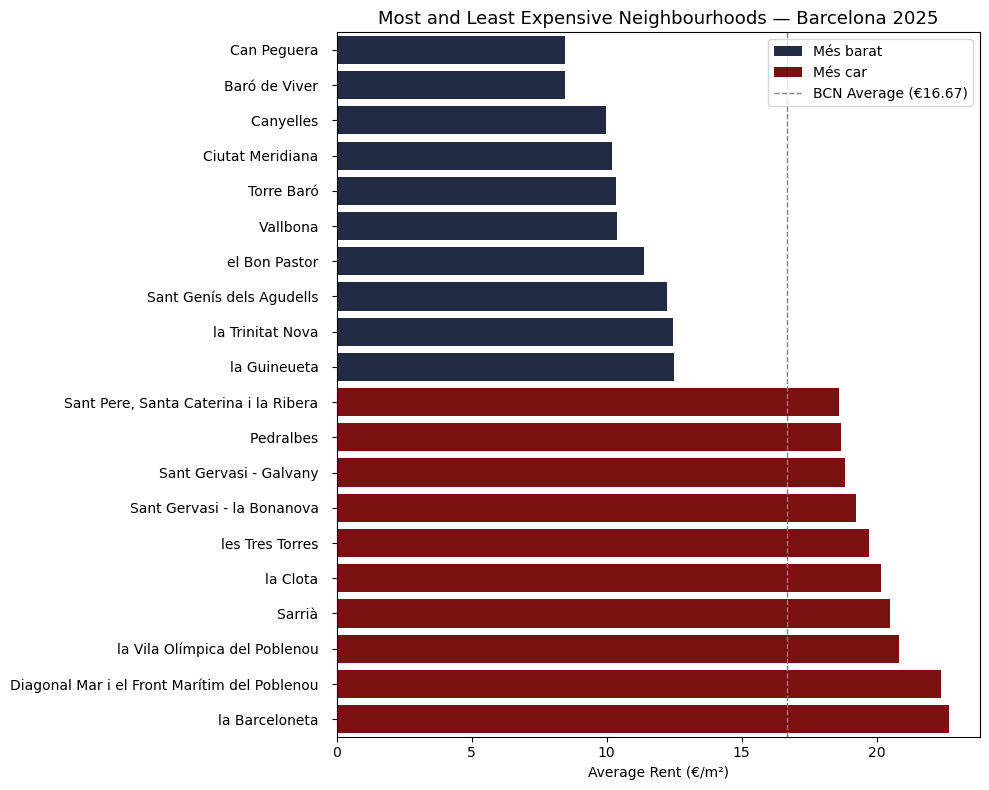

In [24]:
plt.figure(figsize=(10, 8))

sns.barplot(data=df_top, x='Preu_m2', y='Barris', hue='tipo',
            palette={'Higher': '#8B0000', 'Lowe': '#1B2A4A'})

plt.title('Most and Least Expensive Neighbourhoods — Barcelona 2025', fontsize=13)
plt.xlabel('Average Rent (€/m²)')
plt.ylabel('')
plt.axvline(x=16.67, color='gray', linestyle='--', linewidth=1, label='BCN Average (€16.67)')
plt.legend()
plt.tight_layout()
plt.show()

In [6]:
import pandas as pd
import numpy as np

df_barris = pd.read_csv('bcn_rent_barris_long.csv')

df_barris.head()

,Codi,Barris,Any,Preu_m2
0,1,el Raval,2014,10.470000
1,1,el Raval,2015,11.104500
2,1,el Raval,2016,12.263660
3,1,el Raval,2017,13.915648
4,1,el Raval,2018,14.015729


In [7]:
df_barris.shape

(876, 4)

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

In [16]:
bcn_media = df_barris.groupby('Any')['Preu_m2'].mean().reset_index()

bcn_media

,Any,Preu_m2
0,2014,9.539167
1,2015,10.266042
2,2016,11.292923
3,2017,12.495710
4,2018,12.528543
5,2019,13.019394
6,2020,13.083727
7,2021,12.453579
8,2022,13.573405
9,2023,15.216403


#### 9.3 Average Rent Evolution in Barcelona (2014–2025)

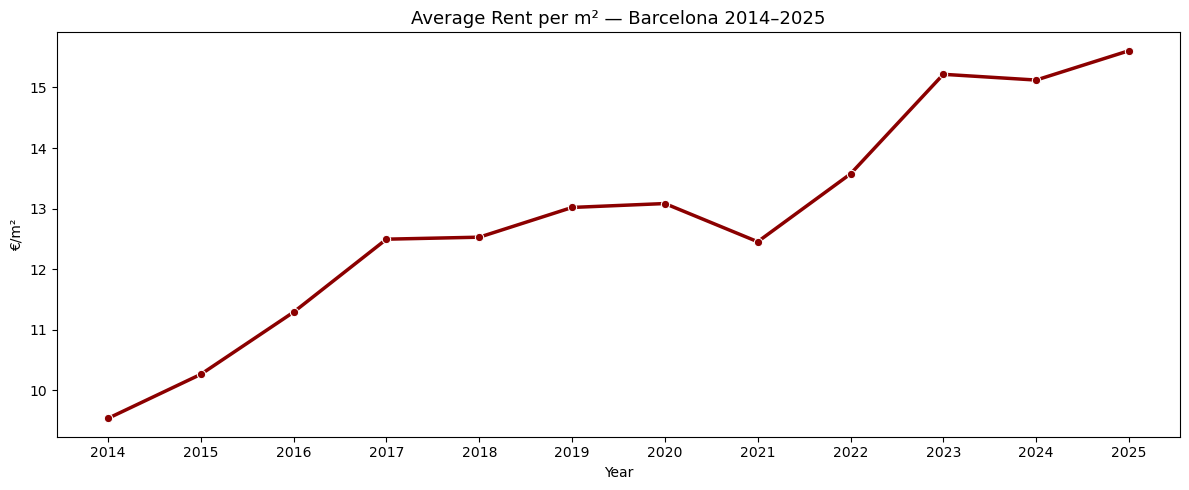

In [10]:
plt.figure(figsize=(12, 5))

sns.lineplot(data=bcn_media, x='Any', y='Preu_m2', 
             color='#8B0000', linewidth=2.5, marker='o')

plt.title('Average Rent per m² — Barcelona 2014–2025', fontsize=13)
plt.xlabel('Year')
plt.ylabel('€/m²')
plt.xticks(bcn_media['Any'])
plt.tight_layout()
plt.show()

### 10. The Invisible Market: Room Rentals in Barcelona

Official datasets do not capture the room rental market, as it operates largely 
outside formal regulation — a policy gap that is itself a finding of this study. 
What is not measured cannot be regulated.

Reports from major platforms provide consistent evidence of an accelerating price trend:

**Spain (national average):**
- 2015: €262/month (Fotocasa)
- 2022: €329/month (Fotocasa)
- 2024: €445/month (Fotocasa)
- 2025: €510/month (Fotocasa)

**Barcelona specifically:**
- 2025: €570/month (Idealista)
- 2025: €620/month (Spotahome)

Barcelona is the most expensive city in Spain for room rentals — with prices 
117% higher than the national average in 2015, rising to levels that exceed 
50% of the minimum wage (€1,134/month) for a single room.

The absence of a public historical series for room rental prices in Barcelona 
is not a data limitation — it is a regulatory choice. The informal room rental 
market operates in a legal grey zone that benefits landlords and leaves tenants 
without protection, data, or recourse.

### 11. Loading Idealista Historical Price Series

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df_barris = pd.read_csv('bcn_rent_barris_long.csv')
df_idealista = pd.read_csv('idealista.txt', sep='\t', encoding='utf-8')

df_idealista.head()

,,,,Histórico de precios de alquiler en Barcelona
Mes,Precio m2,Variación mensual,Variación trimestral,Variación anual
Mayo 2026,"22,5 €/m2","+ 2,2 %","- 3,9 %","- 6,1 %"
Abril 2026,"22,0 €/m2","- 2,9 %","- 8,3 %","- 7,6 %"
Marzo 2026,"22,6 €/m2","- 3,2 %","- 5,1 %","- 3,7 %"
Febrero 2026,"23,4 €/m2","- 2,4 %","- 2,7 %","- 1,2 %"


In [3]:
df_idealista = pd.read_csv('idealista.txt', sep='\t', encoding='utf-8', skiprows=1)

df_idealista.head()

,Mes,Precio m2,Variación mensual,Variación trimestral,Variación anual
0,Mayo 2026,"22,5 €/m2","+ 2,2 %","- 3,9 %","- 6,1 %"
1,Abril 2026,"22,0 €/m2","- 2,9 %","- 8,3 %","- 7,6 %"
2,Marzo 2026,"22,6 €/m2","- 3,2 %","- 5,1 %","- 3,7 %"
3,Febrero 2026,"23,4 €/m2","- 2,4 %","- 2,7 %","- 1,2 %"
4,Enero 2026,"24,0 €/m2","+ 0,5 %","- 1,5 %","+ 1,5 %"


### 12. Cleaning Idealista Price Series

The `Precio m2` column requires cleaning: removing the '€/m2' string, 
replacing comma decimal separators with periods, and converting to float.

In [5]:
df_idealista['Precio m2'] = (df_idealista['Precio m2']
    .str.replace(' €/m2', '', regex=False)
    .str.replace(',', '.', regex=False)
    .astype(float))

df_idealista.head()

,Mes,Precio m2,Variación mensual,Variación trimestral,Variación anual
0,Mayo 2026,22.5,"+ 2,2 %","- 3,9 %","- 6,1 %"
1,Abril 2026,22.0,"- 2,9 %","- 8,3 %","- 7,6 %"
2,Marzo 2026,22.6,"- 3,2 %","- 5,1 %","- 3,7 %"
3,Febrero 2026,23.4,"- 2,4 %","- 2,7 %","- 1,2 %"
4,Enero 2026,24.0,"+ 0,5 %","- 1,5 %","+ 1,5 %"


In [6]:
df_idealista = df_idealista[['Mes', 'Precio m2', 'Variación mensual']]

In [7]:
df_idealista = df_idealista.rename(columns={
    'Mes': 'Month',
    'Precio m2': 'Price_m2',
    'Variación mensual': 'Monthly_Variation'
})

df_idealista.head()

,Month,Price_m2,Monthly_Variation
0,Mayo 2026,22.5,"+ 2,2 %"
1,Abril 2026,22.0,"- 2,9 %"
2,Marzo 2026,22.6,"- 3,2 %"
3,Febrero 2026,23.4,"- 2,4 %"
4,Enero 2026,24.0,"+ 0,5 %"


In [8]:
meses = {
    'Enero': 'January', 'Febrero': 'February', 'Marzo': 'March',
    'Abril': 'April', 'Mayo': 'May', 'Junio': 'June',
    'Julio': 'July', 'Agosto': 'August', 'Septiembre': 'September',
    'Octubre': 'October', 'Noviembre': 'November', 'Diciembre': 'December'
}

df_idealista['Month'] = df_idealista['Month'].replace(meses, regex=True)

df_idealista.head()

,Month,Price_m2,Monthly_Variation
0,May 2026,22.5,"+ 2,2 %"
1,April 2026,22.0,"- 2,9 %"
2,March 2026,22.6,"- 3,2 %"
3,February 2026,23.4,"- 2,4 %"
4,January 2026,24.0,"+ 0,5 %"


In [9]:
df_idealista['Month'] = pd.to_datetime(df_idealista['Month'], format='%B %Y')
df_idealista['Year'] = df_idealista['Month'].dt.year

df_idealista.head()

,Month,Price_m2,Monthly_Variation,Year
0,2026-05-01,22.5,"+ 2,2 %",2026
1,2026-04-01,22.0,"- 2,9 %",2026
2,2026-03-01,22.6,"- 3,2 %",2026
3,2026-02-01,23.4,"- 2,4 %",2026
4,2026-01-01,24.0,"+ 0,5 %",2026


In [10]:
bcnhab_media = df_idealista.groupby('Year')['Price_m2'].mean().reset_index()

In [11]:
bcnhab_media.head()

,Year,Price_m2
0,2008,15.057143
1,2009,14.433333
2,2010,13.475000
3,2011,12.316667
4,2012,11.658333


In [12]:
bcnhab_media

,Year,Price_m2
0,2008,15.057143
1,2009,14.433333
2,2010,13.475000
3,2011,12.316667
4,2012,11.658333
5,2013,10.958333
6,2014,11.175000
7,2015,12.366667
8,2016,14.266667
9,2017,16.108333


In [13]:
bcnhab_media_filter = bcnhab_media[(bcnhab_media['Year'] >= 2014) & (bcnhab_media['Year'] <= 2025)]

In [14]:
bcnhab_media_filter

,Year,Price_m2
6,2014,11.175000
7,2015,12.366667
8,2016,14.266667
9,2017,16.108333
10,2018,16.208333
11,2019,16.200000
12,2020,15.925000
13,2021,14.333333
14,2022,16.433333
15,2023,19.250000


In [17]:
bcn_media.to_csv('bcn_rent_incasol_annual.csv', index=False)
bcnhab_media_filter.to_csv('bcn_rent_idealista_annual.csv', index=False)

print("Files saved successfully.")

Files saved successfully.


In [19]:
bcn_media

,Any,Preu_m2
0,2014,9.539167
1,2015,10.266042
2,2016,11.292923
3,2017,12.495710
4,2018,12.528543
5,2019,13.019394
6,2020,13.083727
7,2021,12.453579
8,2022,13.573405
9,2023,15.216403


In [20]:
bcn_media = bcn_media.rename(columns={
    'Any': 'Year',
    'Preu_m2': 'Price_m2',
})

bcn_media.head()

,Year,Price_m2
0,2014,9.539167
1,2015,10.266042
2,2016,11.292923
3,2017,12.495710
4,2018,12.528543


In [21]:
bcn_media.to_csv('bcn_rent_incasol_annual.csv', index=False)
bcnhab_media_filter.to_csv('bcn_rent_idealista_annual.csv', index=False)

print("Files saved successfully.")

Files saved successfully.


In [22]:
df_compare = bcn_media.merge(bcnhab_media_filter, on='Year', suffixes=('_incasol', '_idealista'))

df_compare

,Year,Price_m2_incasol,Price_m2_idealista
0,2014,9.539167,11.175000
1,2015,10.266042,12.366667
2,2016,11.292923,14.266667
3,2017,12.495710,16.108333
4,2018,12.528543,16.208333
5,2019,13.019394,16.200000
6,2020,13.083727,15.925000
7,2021,12.453579,14.333333
8,2022,13.573405,16.433333
9,2023,15.216403,19.250000


### 13. The Paradox: Official Contract Prices vs Market Asking Prices (2014–2025)

INCASÒL data reflects registered contract prices — the metric used by the 
government to claim rent control is working. Idealista data reflects advertised 
market prices — what renters actually face when searching for a home.
The divergence between these two series is the central paradox of this study.

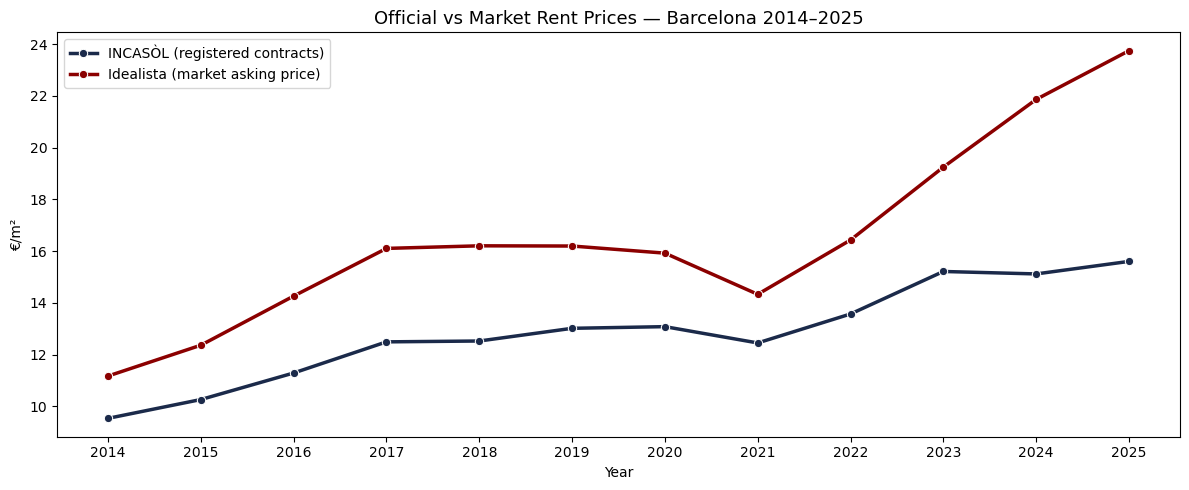

In [23]:
plt.figure(figsize=(12, 5))

sns.lineplot(data=df_compare, x='Year', y='Price_m2_incasol',
             color='#1B2A4A', linewidth=2.5, marker='o', label='INCASÒL (registered contracts)')

sns.lineplot(data=df_compare, x='Year', y='Price_m2_idealista',
             color='#8B0000', linewidth=2.5, marker='o', label='Idealista (market asking price)')

plt.title('Official vs Market Rent Prices — Barcelona 2014–2025', fontsize=13)
plt.xlabel('Year')
plt.ylabel('€/m²')
plt.xticks(df_compare['Year'])
plt.legend()
plt.tight_layout()
plt.show()

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df_barris = pd.read_csv('bcn_rent_barris_long.csv')
df_incasol = pd.read_csv('bcn_rent_incasol_annual.csv')
df_idealista = pd.read_csv('bcn_rent_idealista_annual.csv')


In [2]:
df_barris[df_barris['Barris'].isin([
    'la Barceloneta', 
    'el Barri Gòtic',
    'la Dreta de l\'Eixample',
    'Gràcia',
    'el Poblenou'
])]['Barris'].unique()

<StringArray>
[]
Length: 0, dtype: str

In [3]:
df_barris['Barris'].unique()

<StringArray>
[                                    'el Raval  ',
                               'el Barri Gòtic  ',
                               'la Barceloneta  ',
        'Sant Pere, Santa Caterina i la Ribera  ',
                                'el Fort Pienc  ',
                           'la Sagrada Família  ',
                       'la Dreta de l'Eixample  ',
              'l'Antiga Esquerra de l'Eixample  ',
               'la Nova Esquerra de l'Eixample  ',
                                  'Sant Antoni  ',
             'el Poble Sec - AEI Parc Montjuïc  ',
 'la Marina del Prat Vermell - AEI Zona Franca  ',
                            'la Marina de Port  ',
                        'la Font de la Guatlla  ',
                                  'Hostafrancs  ',
                                   'la Bordeta  ',
                                'Sants - Badal  ',
                                        'Sants  ',
                                    'les Corts  ',
                 

In [4]:
df_barris['Barris'] = df_barris['Barris'].str.strip()

In [6]:
bairros_narrativa = [
    'la Barceloneta',
    'el Barri Gòtic',
    'el Poblenou',
    'la Vila de Gràcia',
    "la Dreta de l'Eixample"
]

df_narrativa = df_barris[df_barris['Barris'].isin(bairros_narrativa)]

In [7]:
df_narrativa['Barris'].unique()

<StringArray>
[        'el Barri Gòtic',         'la Barceloneta', 'la Dreta de l'Eixample',
      'la Vila de Gràcia',            'el Poblenou']
Length: 5, dtype: str

### 14. Price Evolution in Barcelona's Most Pressured Neighbourhoods (2014–2025)

Neighbourhood selection is based on documented concentration of tourism, 
coliving, and digital nomad activity (CBRE, Idealista Research 2025):

- **Eixample**: largest international community, coliving in rapid expansion
- **Gràcia**: expat hub, growing international presence
- **Poblenou**: tech workers, 22@ innovation district
- **Barceloneta**: mass tourism, highest HUT concentration in the city
- **Barri Gòtic**: historic centre, tourist saturation

Coliving in Barcelona grew 172% in 2024, with 93% average occupancy 
and prices averaging €886/month per room (CBRE, 2025).

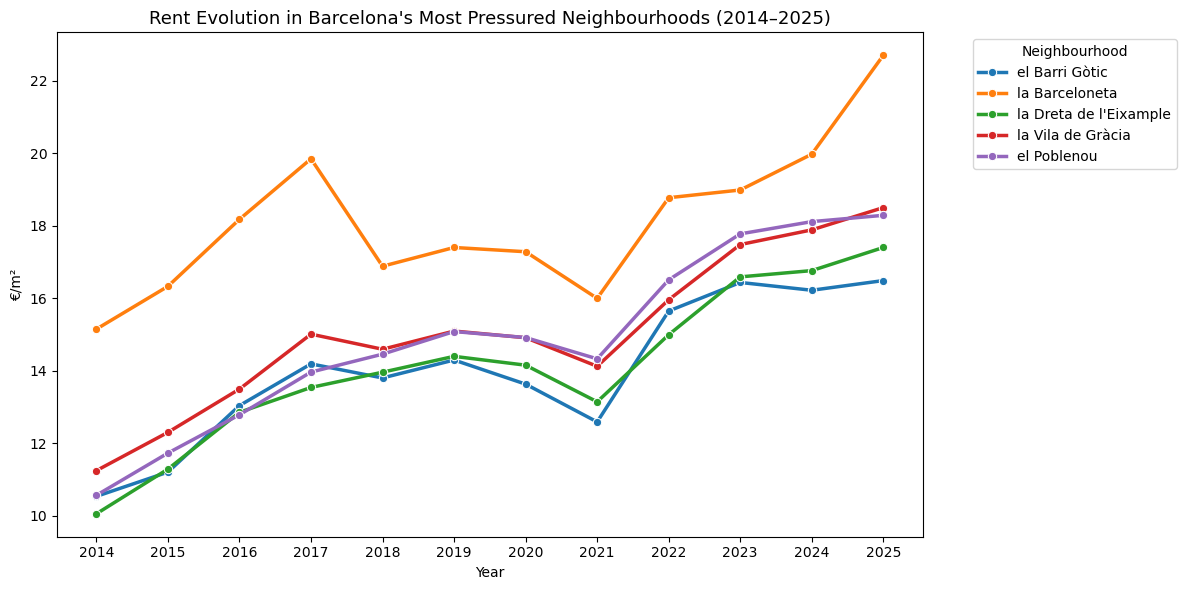

In [9]:
plt.figure(figsize=(12, 6))

sns.lineplot(data=df_narrativa, x='Any', y='Preu_m2', 
             hue='Barris', linewidth=2.5, marker='o')

plt.title("Rent Evolution in Barcelona's Most Pressured Neighbourhoods (2014–2025)", fontsize=13)
plt.xlabel('Year')
plt.ylabel('€/m²')
plt.xticks(df_narrativa['Any'].unique())
plt.legend(title='Neighbourhood', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### 15. Before and After: The Impact of Ley de Vivienda 2023

Comparing average rent per m² in 2022 (pre-law) vs 2024 (post-law) 
across Barcelona's most pressured neighbourhoods.

In [10]:
df_before_after = df_narrativa[df_narrativa['Any'].isin([2022, 2024])]

In [11]:
df_narrativa.head()

,Codi,Barris,Any,Preu_m2
12,2,el Barri Gòtic,2014,10.540000
13,2,el Barri Gòtic,2015,11.209400
14,2,el Barri Gòtic,2016,13.042661
15,2,el Barri Gòtic,2017,14.191885
16,2,el Barri Gòtic,2018,13.804200


In [12]:
df_before_after = df_narrativa[df_narrativa['Any'].isin([2022, 2024])]
df_before_after.head(10)

,Codi,Barris,Any,Preu_m2
20,2,el Barri Gòtic,2022,15.648701
22,2,el Barri Gòtic,2024,16.221309
32,3,la Barceloneta,2022,18.771757
34,3,la Barceloneta,2024,19.971922
80,7,la Dreta de l'Eixample,2022,14.995865
82,7,la Dreta de l'Eixample,2024,16.762918
368,31,la Vila de Gràcia,2022,15.958940
370,31,la Vila de Gràcia,2024,17.885784
812,68,el Poblenou,2022,16.508805
814,68,el Poblenou,2024,18.113001


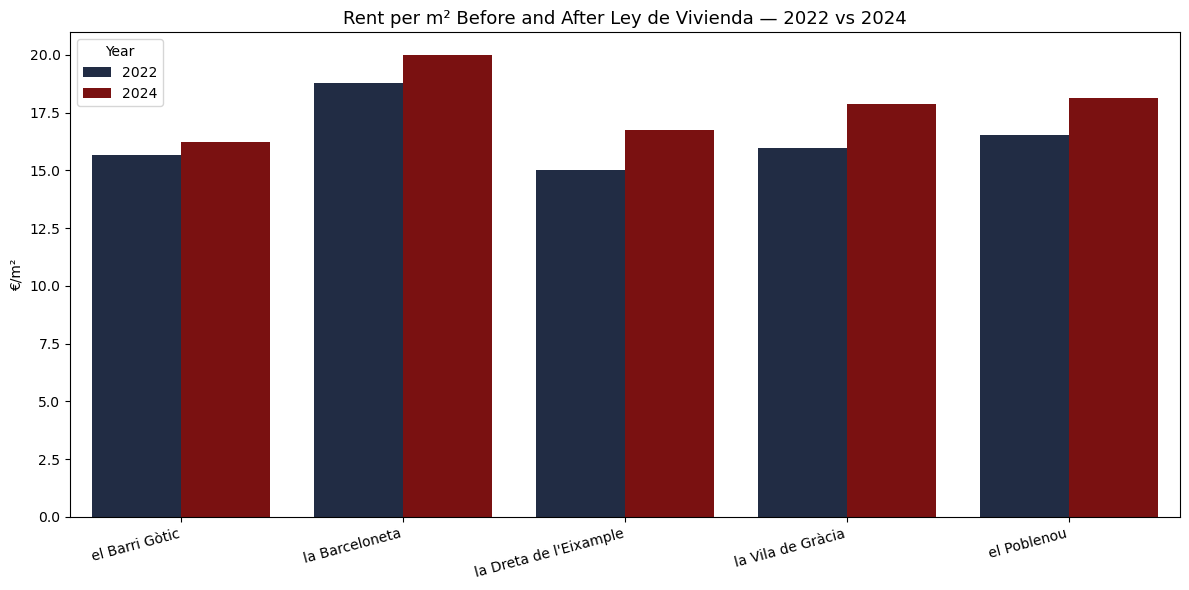

In [13]:
plt.figure(figsize=(12, 6))

sns.barplot(data=df_before_after, x='Barris', y='Preu_m2', 
            hue='Any', palette={2022: '#1B2A4A', 2024: '#8B0000'})

plt.title('Rent per m² Before and After Ley de Vivienda — 2022 vs 2024', fontsize=13)
plt.xlabel('')
plt.ylabel('€/m²')
plt.xticks(rotation=15, ha='right')
plt.legend(title='Year')
plt.tight_layout()
plt.show()

### 16. Analytical Conclusions

The data tells a consistent story across all sources and methodologies:

1. **A decade of unaffordability**: Average rent per m² in Barcelona's most 
pressured neighbourhoods grew over 60% between 2014 and 2025, far outpacing 
wage growth and inflation.

2. **The law's paradox**: The Ley de Vivienda 2023 reduced registered contract 
prices marginally — while market asking prices (Idealista) accelerated sharply, 
reaching €23.7/m² in 2025 vs €15.6/m² in official data. The gap between these 
two series is the central paradox of this study.

3. **Coastal gentrification**: Barceloneta, a historic fishing neighbourhood, 
is now Barcelona's most expensive neighbourhood per m² — driven by tourist 
apartment concentration, not traditional wealth.

4. **The invisible market**: Room rentals — where the most vulnerable renters 
operate — remain entirely outside regulatory reach, with prices reaching 
€570–620/month in 2025, exceeding 50% of the minimum wage.

5. **Economic filtering**: The housing market increasingly selects for 
high-income residents, displacing essential workers to peripheral municipalities 
such as Santa Coloma and Badalona.

**The law protected those who already had stability. It abandoned those who 
needed it most.**

In [14]:
df_narrativa.to_csv('bcn_rent_narrativa.csv', index=False)
df_before_after.to_csv('bcn_rent_before_after.csv', index=False)

print("Files saved successfully.")

Files saved successfully.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df_barris = pd.read_csv('bcn_rent_barris_long.csv')
df_incasol = pd.read_csv('bcn_rent_incasol_annual.csv')
df_idealista = pd.read_csv('bcn_rent_idealista_annual.csv')
df_before_after = pd.read_csv('bcn_rent_before_after.csv')

In [2]:
df_before_after

,Codi,Barris,Any,Preu_m2
0,2,el Barri Gòtic,2022,15.648701
1,2,el Barri Gòtic,2024,16.221309
2,3,la Barceloneta,2022,18.771757
3,3,la Barceloneta,2024,19.971922
4,7,la Dreta de l'Eixample,2022,14.995865
5,7,la Dreta de l'Eixample,2024,16.762918
6,31,la Vila de Gràcia,2022,15.958940
7,31,la Vila de Gràcia,2024,17.885784
8,68,el Poblenou,2022,16.508805
9,68,el Poblenou,2024,18.113001


In [3]:
df_before_after.to_csv('bcn_rent_before_after.csv', index=False)

print("Files saved successfully.")

Files saved successfully.


In [4]:
import pandas as pd

df_incasol = pd.read_csv('bcn_rent_incasol_annual.csv')
df_incasol['Price_m2'] = df_incasol['Price_m2'].round(2)
df_incasol.to_csv('bcn_rent_incasol_annual.csv', index=False)

df_idealista = pd.read_csv('bcn_rent_idealista_annual.csv')
df_idealista['Price_m2'] = df_idealista['Price_m2'].round(2)
df_idealista.to_csv('bcn_rent_idealista_annual.csv', index=False)

print("Done!")

Done!


In [5]:
import pandas as pd

df_incasol = pd.read_csv('bcn_rent_incasol_annual.csv')
print(df_incasol)

    Year  Price_m2
0   2014      9.54
1   2015     10.27
2   2016     11.29
3   2017     12.50
4   2018     12.53
5   2019     13.02
6   2020     13.08
7   2021     12.45
8   2022     13.57
9   2023     15.22
10  2024     15.12
11  2025     15.61


In [6]:
import pandas as pd

arquivos = [
    'bcn_rent_incasol_annual.csv',
    'bcn_rent_idealista_annual.csv',
    'bcn_rent_narrativa.csv',
    'bcn_rent_before_after.csv',
    'bcn_rent_barris_long.csv'
]

for arquivo in arquivos:
    df = pd.read_csv(arquivo)
    colunas_numericas = df.select_dtypes(include='float').columns
    df[colunas_numericas] = df[colunas_numericas].round(2)
    df.to_csv(arquivo, index=False, float_format='%.2f')
    print(f"✓ {arquivo}")

print("\nAll files saved!")

✓ bcn_rent_incasol_annual.csv
✓ bcn_rent_idealista_annual.csv
✓ bcn_rent_narrativa.csv
✓ bcn_rent_before_after.csv
✓ bcn_rent_barris_long.csv

All files saved!


In [7]:
import pandas as pd

df = pd.read_csv('bcn_rent_before_after.csv')
print(df.head())

   Codi                  Barris   Any  Preu_m2
0     2          el Barri Gòtic  2022    15.65
1     2          el Barri Gòtic  2024    16.22
2     3          la Barceloneta  2022    18.77
3     3          la Barceloneta  2024    19.97
4     7  la Dreta de l'Eixample  2022    15.00


In [8]:
import pandas as pd

arquivos = [
    'bcn_rent_incasol_annual.csv',
    'bcn_rent_idealista_annual.csv',
    'bcn_rent_narrativa.csv',
    'bcn_rent_before_after.csv',
    'bcn_rent_barris_long.csv'
]

for arquivo in arquivos:
    df = pd.read_csv(arquivo)
    print(f"\n{arquivo}")
    print(df.head(3))


bcn_rent_incasol_annual.csv
   Year  Price_m2
0  2014      9.54
1  2015     10.27
2  2016     11.29

bcn_rent_idealista_annual.csv
   Year  Price_m2
0  2014     11.18
1  2015     12.37
2  2016     14.27

bcn_rent_narrativa.csv
   Codi          Barris   Any  Preu_m2
0     2  el Barri Gòtic  2014    10.54
1     2  el Barri Gòtic  2015    11.21
2     2  el Barri Gòtic  2016    13.04

bcn_rent_before_after.csv
   Codi          Barris   Any  Preu_m2
0     2  el Barri Gòtic  2022    15.65
1     2  el Barri Gòtic  2024    16.22
2     3  la Barceloneta  2022    18.77

bcn_rent_barris_long.csv
   Codi      Barris   Any  Preu_m2
0     1  el Raval    2014    10.47
1     1  el Raval    2015    11.10
2     1  el Raval    2016    12.26


In [9]:
import pandas as pd

df_idealista = pd.read_csv('bcn_rent_idealista_annual.csv')
df_idealista = df_idealista.rename(columns={'Price_m2': 'Asking_Price_m2'})
df_idealista.to_csv('bcn_rent_idealista_annual.csv', index=False, float_format='%.2f')

print(df_idealista.head())

   Year  Asking_Price_m2
0  2014            11.18
1  2015            12.37
2  2016            14.27
3  2017            16.11
4  2018            16.21


In [10]:
import pandas as pd

df_incasol = pd.read_csv('bcn_rent_incasol_annual.csv')
df_idealista = pd.read_csv('bcn_rent_idealista_annual.csv')

df_compare = df_incasol.merge(df_idealista, on='Year')
df_compare.to_csv('bcn_rent_compare.csv', index=False, float_format='%.2f')

print(df_compare)

    Year  Price_m2  Asking_Price_m2
0   2014      9.54            11.18
1   2015     10.27            12.37
2   2016     11.29            14.27
3   2017     12.50            16.11
4   2018     12.53            16.21
5   2019     13.02            16.20
6   2020     13.08            15.92
7   2021     12.45            14.33
8   2022     13.57            16.43
9   2023     15.22            19.25
10  2024     15.12            21.87
11  2025     15.61            23.75


In [11]:
import pandas as pd

df_compare = pd.read_csv('bcn_rent_compare.csv')
df_compare.to_csv('bcn_rent_compare.csv', index=False, float_format='%.2f', decimal=',', sep=';')

print(df_compare)

    Year  Price_m2  Asking_Price_m2
0   2014      9.54            11.18
1   2015     10.27            12.37
2   2016     11.29            14.27
3   2017     12.50            16.11
4   2018     12.53            16.21
5   2019     13.02            16.20
6   2020     13.08            15.92
7   2021     12.45            14.33
8   2022     13.57            16.43
9   2023     15.22            19.25
10  2024     15.12            21.87
11  2025     15.61            23.75


In [12]:
import pandas as pd

df_compare = pd.read_csv('bcn_rent_compare.csv')
df_compare.to_csv('bcn_rent_compare.csv', index=False, float_format='%.2f')

print(df_compare)

               Year;Price_m2;Asking_Price_m2
2014;9  54;11                             18
2015;10 27;12                             37
2016;11 29;14                             27
2017;12 50;16                             11
2018;12 53;16                             21
2019;13 02;16                             20
2020;13 08;15                             92
2021;12 45;14                             33
2022;13 57;16                             43
2023;15 22;19                             25
2024;15 12;21                             87
2025;15 61;23                             75


In [13]:
import pandas as pd

df_incasol = pd.read_csv('bcn_rent_incasol_annual.csv')
df_idealista = pd.read_csv('bcn_rent_idealista_annual.csv')

df_compare = df_incasol.merge(df_idealista, on='Year')
df_compare['Price_m2'] = df_compare['Price_m2'].round(2)
df_compare['Asking_Price_m2'] = df_compare['Asking_Price_m2'].round(2)

df_compare.to_csv('bcn_rent_compare.csv', index=False)

print(df_compare)

    Year  Price_m2  Asking_Price_m2
0   2014      9.54            11.18
1   2015     10.27            12.37
2   2016     11.29            14.27
3   2017     12.50            16.11
4   2018     12.53            16.21
5   2019     13.02            16.20
6   2020     13.08            15.92
7   2021     12.45            14.33
8   2022     13.57            16.43
9   2023     15.22            19.25
10  2024     15.12            21.87
11  2025     15.61            23.75


In [14]:
import pandas as pd

df_compare = pd.read_csv('bcn_rent_compare.csv')
df_compare.to_csv('bcn_rent_compare_eu.csv', index=False, float_format='%.2f', decimal=',', sep=';')

print("Saved!")

Saved!


In [15]:
import pandas as pd

df_compare = pd.read_csv('bcn_rent_compare.csv')
df_compare = df_compare.round(2)

# Força 2 casas decimais em todos os valores
df_compare.to_csv('bcn_rent_compare.csv', index=False, float_format='%.2f')

In [16]:
import pandas as pd

df_compare = pd.read_csv('bcn_rent_compare.csv')
df_compare['Price_m2'] = df_compare['Price_m2'].astype(str)
df_compare['Asking_Price_m2'] = df_compare['Asking_Price_m2'].astype(str)
df_compare.to_csv('bcn_rent_compare.csv', index=False)

In [17]:
import pandas as pd

df_compare = pd.read_csv('bcn_rent_compare.csv')
df_compare = df_compare.rename(columns={'Asking_Price_m2': 'Asking_Price'})
df_compare.to_csv('bcn_rent_compare.csv', index=False)

print(df_compare.columns.tolist())

['Year', 'Price_m2', 'Asking_Price']
